# Understanding post-purchase experience, dissatisfaction, and silent customers

### Business questions

1. What factors in the post-purchase journey are associated with customer dissatisfaction among reviewed orders?

2. How do reviewed and non-reviewed orders differ, and what does that reveal about silent customers?

3. How does post-purchase experience relate to customer behavior, including repeat purchase patterns?

4. Can we predict which reviewed orders are at risk of dissatisfaction based on known experience features?

5. As a strategic extension, how might acquisition channels shape expectations before the post-purchase experience begins?

### Central Thesis

Customer dissatisfaction in e-commerce is not just a service issue; it is a signal that the brand promise failed in the post-purchase experience.



### Table of Contents (Charts)

- Chart 1: review participation rate
- Chart 2: dissatisfaction rate among reviewed orders
- Chart 3: delivery delay distribution
- Chart 4: average delivery delay vs dissatisfaction
- Chart 5: dissatisfaction by month
- Chart 6: repeat vs non-repeat customers
- Chart 7: review score distribution
- Chart 8: probability of a written review based on score
- Chart 9: dissatisfaction by order value
- Chart 10: dissatisfaction by delay bucket
- Chart 11: reviewed vs silent customers
- Chart 12: dissatisfaction risk concentration

In [240]:
import pandas as pd
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

processed_path = Path("../") / config["paths"]["processed_data"]
file_name = config["files"]["main_dataset"]
df = pd.read_csv("../data/processed/main_dataset.csv")

In [241]:
import sys
sys.path.append("..")  # adjust if needed

from utils import *

In [242]:
# Keep a reviewed-only subset for dissatisfaction analysis
reviewed_df = df[df["has_review"] == 1].copy()

### 1. Understanding feedback participation and dissatisfaction

In [243]:
# Review participation across all delivered orders
df["has_review"].value_counts(normalize=True) * 100

has_review
1    99.334055
0     0.665945
Name: proportion, dtype: float64

Not all customers leave explicit feedback. That means dissatisfaction is only directly observed for a subset of delivered orders.

This creates two important analytical layers:

- **review participation**: who leaves feedback at all
- **observed dissatisfaction**: among reviewed orders, who reports a poor experience

### Chart 1 — review participation rate

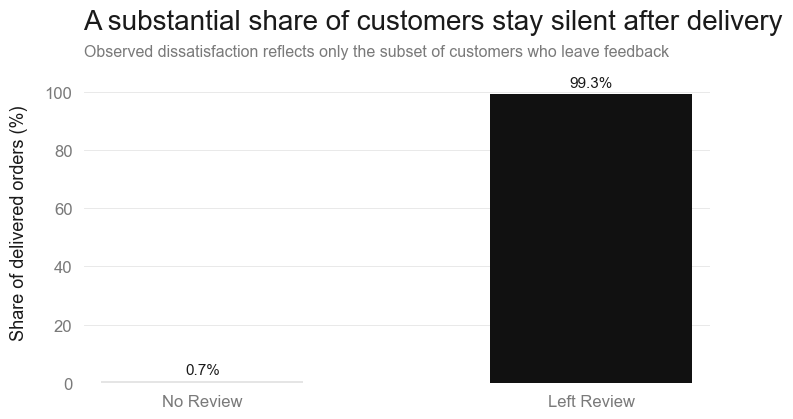

In [277]:
review_rate = df["has_review"].mean() * 100

fig, ax = create_figure(figsize=(8, 5))

labels = ["No Review", "Left Review"]
values = [100 - review_rate, review_rate]
colors = [LIGHT, ACCENT]

bars = ax.bar(labels, values, color=colors, width=0.52)

add_title(
    ax,
    "A substantial share of customers stay silent after delivery",
    "Observed dissatisfaction reflects only the subset of customers who leave feedback"
)

ax.set_ylabel("Share of delivered orders (%)")
ax.set_ylim(0, 110)
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1.2,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "01_review_participation_rate.png")

### Chart 2 — dissatisfaction rate among reviewed orders

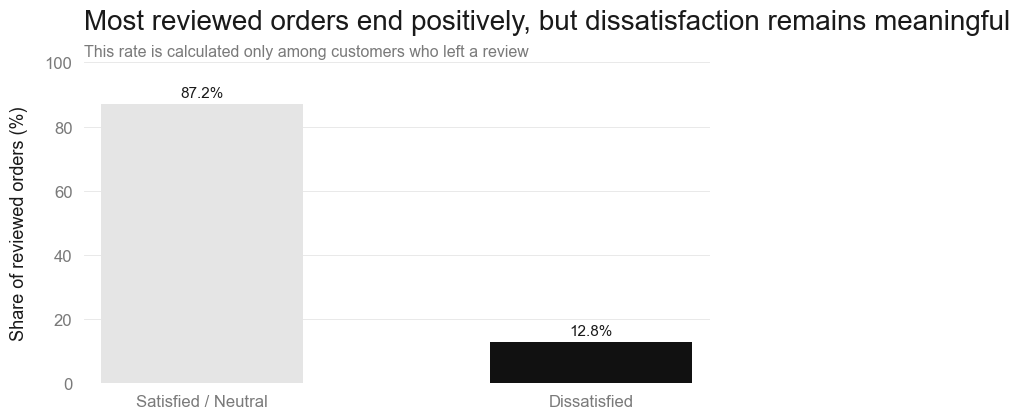

In [245]:
dissatisfaction_rate = reviewed_df["is_dissatisfied"].mean() * 100

fig, ax = create_figure(figsize=(8, 5))

labels = ["Satisfied / Neutral", "Dissatisfied"]
values = [100 - dissatisfaction_rate, dissatisfaction_rate]
colors = [LIGHT, ACCENT]

bars = ax.bar(labels, values, color=colors, width=0.52)

add_title(
    ax,
    "Most reviewed orders end positively, but dissatisfaction remains meaningful",
    "This rate is calculated only among customers who left a review"
)

ax.set_ylabel("Share of reviewed orders (%)")
ax.set_ylim(0, 100)
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 1.2,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "02_dissatisfaction_rate_reviewed_orders.png")

### 2. Core driver: delivery delays

In [246]:
df["delivery_delay"].describe()

count    97005.000000
mean       -11.880790
std         10.183992
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

### 3. Customer behavior layer

In [247]:
# Compare dissatisfaction rates between repeat and non-repeat customers among reviewed orders
reviewed_df.groupby("is_repeat_customer")["is_dissatisfied"].mean() * 100

is_repeat_customer
0    12.875921
1    11.298343
Name: is_dissatisfied, dtype: float64

Repeat customers show slightly lower dissatisfaction rates among reviewed orders.

This suggests an association between customer history and experience outcomes, but it does **not** yet prove that dissatisfaction reduces future repeat purchase.

### Chart 3 — delivery delay distribution

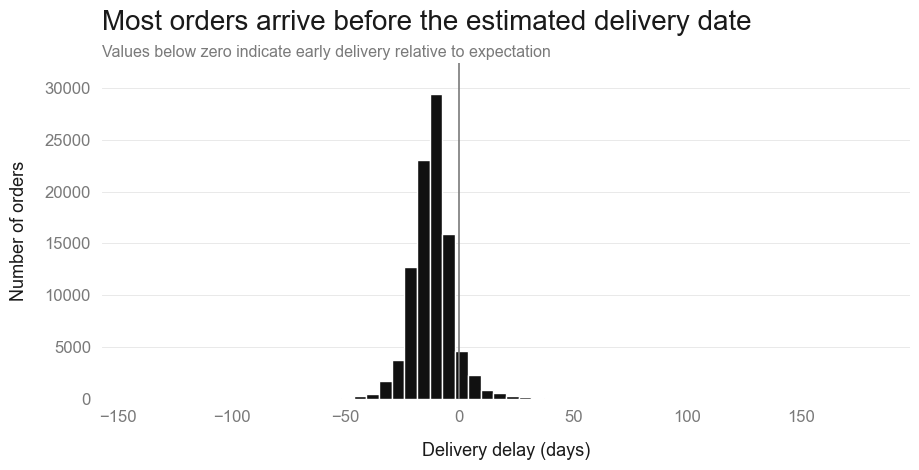

In [248]:
fig, ax = create_figure(figsize=(10, 5.5))

ax.hist(df["delivery_delay"].dropna(), bins=60, color=ACCENT, edgecolor=BG)
ax.axvline(0, color=MID, linewidth=1.2)

add_title(
    ax,
    "Most orders arrive before the estimated delivery date",
    "Values below zero indicate early delivery relative to expectation"
)

ax.set_xlabel("Delivery delay (days)")
ax.set_ylabel("Number of orders")
clean_axes(ax, grid_axis="y")

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "03_delivery_delay_distribution.png")

### Chart 4 — average delivery delay vs dissatisfaction

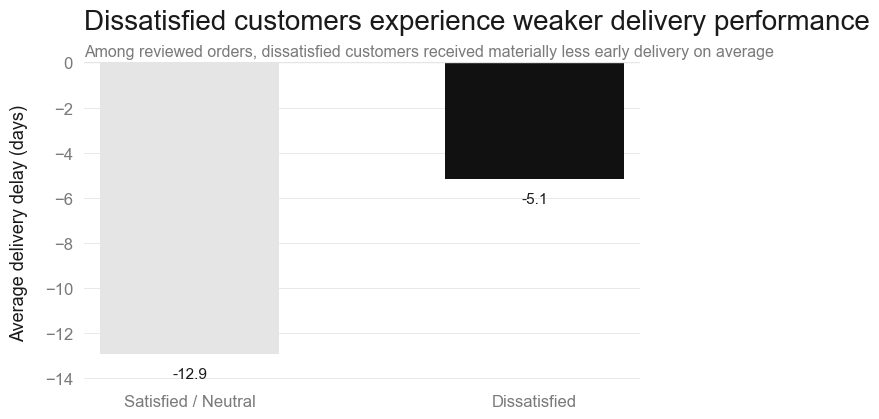

In [249]:
delay_by_group = (
    reviewed_df.groupby("is_dissatisfied")["delivery_delay"]
    .mean()
    .rename(index={0: "Satisfied / Neutral", 1: "Dissatisfied"})
)

fig, ax = create_figure(figsize=(8, 5))

bars = ax.bar(
    delay_by_group.index,
    delay_by_group.values,
    color=[LIGHT, ACCENT],
    width=0.52
)

ax.axhline(0, color=LIGHT, linewidth=1)

add_title(
    ax,
    "Dissatisfied customers experience weaker delivery performance",
    "Among reviewed orders, dissatisfied customers received materially less early delivery on average"
)

ax.set_ylabel("Average delivery delay (days)")
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    offset = 0.4 if h >= 0 else -0.6
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + offset,
        f"{h:.1f}",
        ha="center",
        va="bottom" if h >= 0 else "top",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "04_delay_vs_dissatisfaction_reviewed.png")

Reviewed dissatisfied orders are still early on average, but much less early than satisfied orders.

This suggests that dissatisfaction is related not only to extreme lateness, but also to weaker delivery performance relative to expectation.

This supports an expectation-gap interpretation, though it does not establish causality.

### Chart 5 — dissatisfaction by month (reviewed orders only)

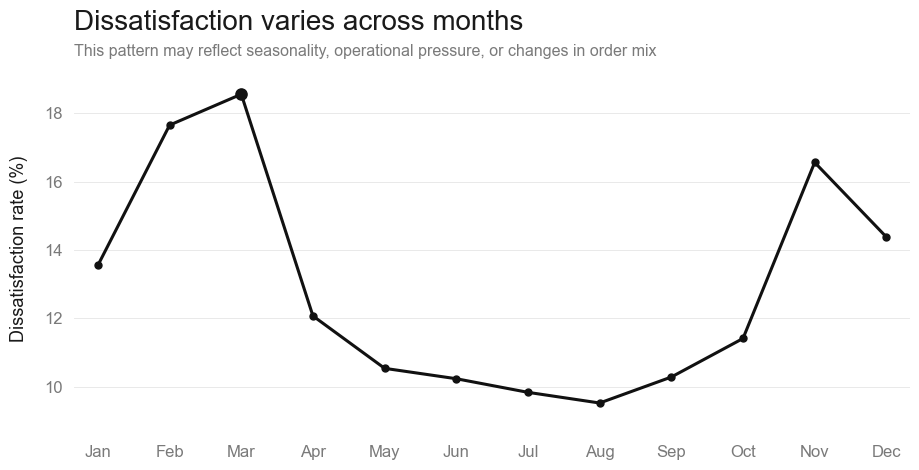

In [250]:
monthly = (
    reviewed_df.groupby(["purchase_month"])["is_dissatisfied"]
    .mean()
    .reset_index()
    .sort_values("purchase_month")
)

monthly["purchase_month_name"] = monthly["purchase_month"].map(
    {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
)

fig, ax = create_figure(figsize=(10, 5.5))

x = monthly["purchase_month_name"]
y = monthly["is_dissatisfied"] * 100

ax.plot(x, y, color=ACCENT, linewidth=2.2, marker="o", markersize=5)

peak_idx = y.idxmax()
ax.scatter(x.iloc[peak_idx], y.iloc[peak_idx], color=ACCENT, s=65, zorder=3)

add_title(
    ax,
    "Dissatisfaction varies across months",
    "This pattern may reflect seasonality, operational pressure, or changes in order mix"
)

ax.set_ylabel("Dissatisfaction rate (%)")
clean_axes(ax, grid_axis="y")

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "05_dissatisfaction_by_month_reviewed.png")

### Chart 6 — repeat vs non-repeat customers

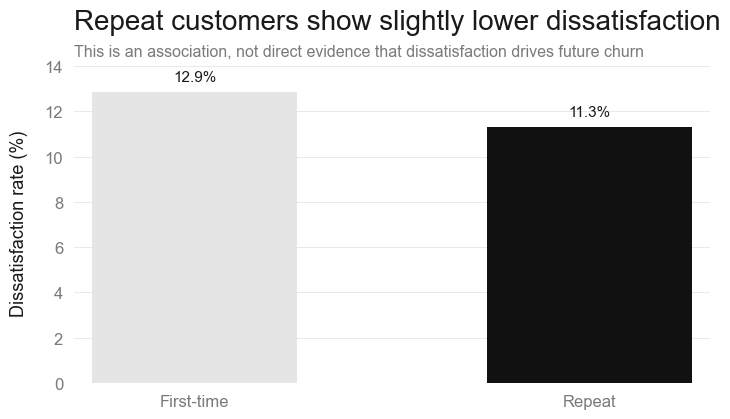

In [251]:
repeat_rates = (
    reviewed_df.groupby("is_repeat_customer")["is_dissatisfied"]
    .mean()
    .rename(index={0: "First-time", 1: "Repeat"})
    * 100
)

fig, ax = create_figure(figsize=(8, 5))

bars = ax.bar(
    repeat_rates.index,
    repeat_rates.values,
    color=[LIGHT, ACCENT],
    width=0.52
)

add_title(
    ax,
    "Repeat customers show slightly lower dissatisfaction",
    "This is an association, not direct evidence that dissatisfaction drives future churn"
)

ax.set_ylabel("Dissatisfaction rate (%)")
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.35,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "06_repeat_customer_dissatisfaction_reviewed.png")

### Chart 7 — review score distribution

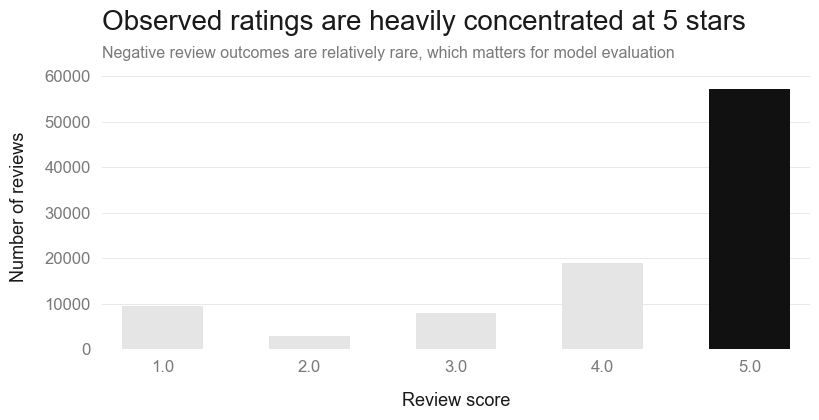

In [252]:
review_dist = reviewed_df["review_score"].value_counts().sort_index()

fig, ax = create_figure(figsize=(9, 5))

bar_colors = [LIGHT, LIGHT, LIGHT, LIGHT, ACCENT]
bars = ax.bar(review_dist.index.astype(str), review_dist.values, color=bar_colors, width=0.55)

add_title(
    ax,
    "Observed ratings are heavily concentrated at 5 stars",
    "Negative review outcomes are relatively rare, which matters for model evaluation"
)

ax.set_xlabel("Review score")
ax.set_ylabel("Number of reviews")
clean_axes(ax, grid_axis="y")

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "07_review_score_distribution.png")

Most observed reviews are positive. That means dissatisfaction is both operationally important and statistically imbalanced, which has implications for modeling and evaluation.

### Core insights so far

1. Not all delivered orders generate explicit feedback  
   This means dissatisfaction is only directly observed for a subset of customers.

2. Delivery performance is the strongest visible operational driver  
   Dissatisfied reviewed orders receive weaker delivery performance on average.

3. Customer history may matter  
   Repeat customers show slightly lower dissatisfaction, though this is not the same as proving dissatisfaction reduces repurchase.

4. Dissatisfaction is a minority class  
   This matters both strategically and for model design.

### Additional Questions:

Does the likelihood of leaving a written review depend on the review score?

In [253]:
reviewed_df["has_written_review"] = (
    reviewed_df["review_comment_message"].notna() |
    reviewed_df["review_comment_title"].notna()
).astype(int)

In [254]:
review_text_rate = (
    reviewed_df.groupby("review_score")["has_written_review"]
    .mean()
    * 100
)

### Chart 8 — probability of a written review based on score

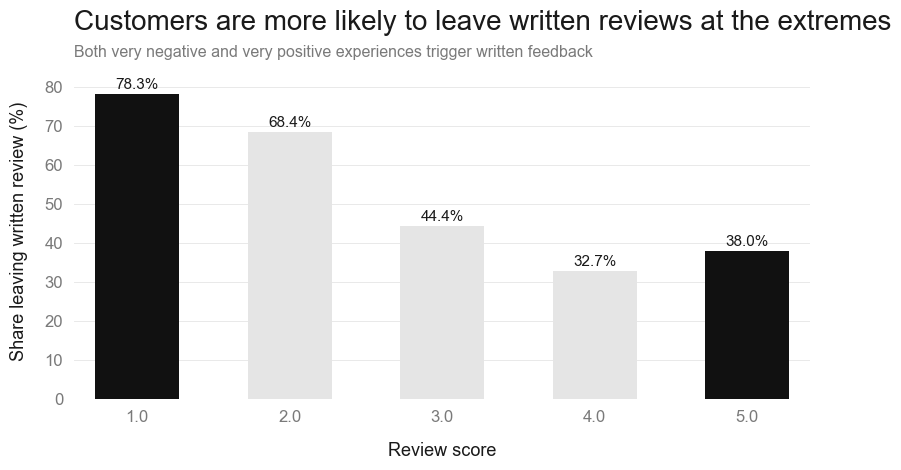

In [255]:
fig, ax = create_figure(figsize=(9, 5.5))

x = review_text_rate.index.astype(str)
y = review_text_rate.values

# Highlight extremes (1-star and 5-star)
colors = [
    ACCENT if score in [1, 5] else LIGHT 
    for score in review_text_rate.index
]

bars = ax.bar(x, y, color=colors, width=0.55)

add_title(
    ax,
    "Customers are more likely to leave written reviews at the extremes",
    "Both very negative and very positive experiences trigger written feedback"
)

ax.set_xlabel("Review score")
ax.set_ylabel("Share leaving written review (%)")

clean_axes(ax, grid_axis="y")

# Add labels
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.6,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()

save_fig(fig, "08_written_review_by_score.png")

### Chart 9 — dissatisfaction by order value

In [256]:
reviewed_df["order_value_band"] = pd.qcut(
    reviewed_df["order_value"],
    q=4,
    labels=["Low", "Mid-Low", "Mid-High", "High"]
)

In [257]:
# Dissatisfaction by order value among reviewed orders
value_diss = (
    reviewed_df.groupby("order_value_band")["is_dissatisfied"]
    .mean()
    * 100
)

/var/folders/0_/937qdrnn19vgx61scsk5r5j40000gn/T/ipykernel_61274/2858852791.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reviewed_df.groupby("order_value_band")["is_dissatisfied"]


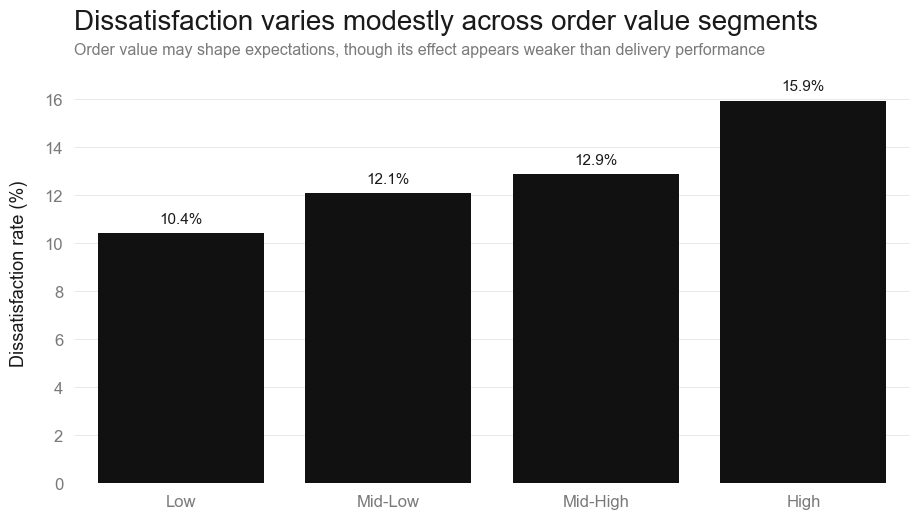

In [258]:
fig, ax = create_figure()

bars = ax.bar(value_diss.index, value_diss.values, color=ACCENT)

add_title(
    ax,
    "Dissatisfaction varies modestly across order value segments",
    "Order value may shape expectations, though its effect appears weaker than delivery performance"
)

ax.set_ylabel("Dissatisfaction rate (%)")
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.3,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()

save_fig(fig, "09_dissatisfaction_by_order_value.png")

Higher-value orders show some variation in dissatisfaction, but the effect appears much weaker than the delivery-performance signal.

In [259]:
reviewed_df["delay_bucket"] = pd.cut(
    reviewed_df["delivery_delay"],
    bins=[-30, -3, 0, 3, 30],
    labels=["Very Early", "Slightly Early", "On Time", "Late"]
)

In [260]:
delay_diss = (
    reviewed_df.groupby("delay_bucket")["is_dissatisfied"]
    .mean()
    * 100
)

/var/folders/0_/937qdrnn19vgx61scsk5r5j40000gn/T/ipykernel_61274/1204489940.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reviewed_df.groupby("delay_bucket")["is_dissatisfied"]


### Chart 10 — dissatisfaction by delay bucket

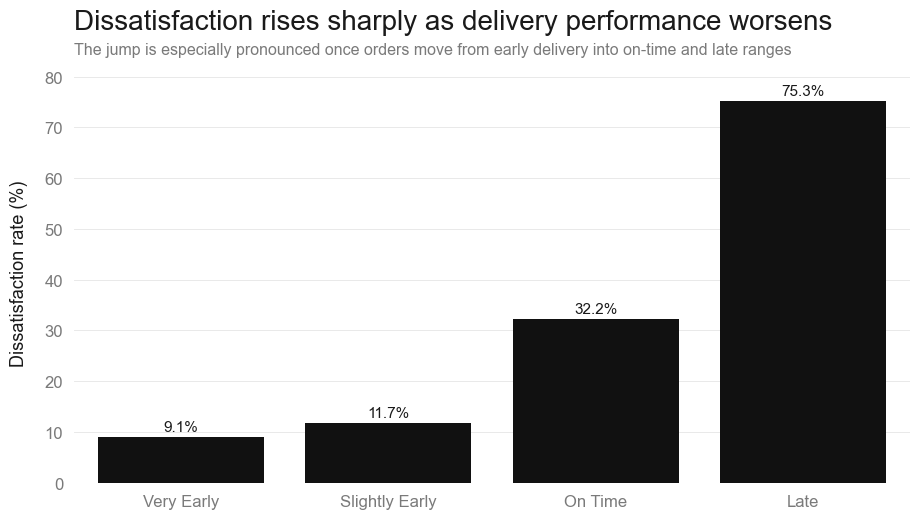

In [261]:
fig, ax = create_figure()

bars = ax.bar(delay_diss.index.astype(str), delay_diss.values, color=ACCENT)

add_title(
    ax,
    "Dissatisfaction rises sharply as delivery performance worsens",
    "The jump is especially pronounced once orders move from early delivery into on-time and late ranges"
)

ax.set_ylabel("Dissatisfaction rate (%)")
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.6,
        f"{h:.1f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()

save_fig(fig, "10_dissatisfaction_by_delay_bucket.png")

Customer dissatisfaction increases dramatically as delivery performance worsens relative to expectation.

This supports the idea that the customer experience is sensitive to expectation gaps, not just a simple late-versus-not-late distinction.

### Chart 11 — reviewed vs silent customers

In [262]:
review_behavior = (
    df.groupby("has_review")[["delivery_delay", "order_value", "product_count", "avg_price_per_item"]]
    .mean()
    .rename(index={0: "No Review", 1: "Left Review"})
)

review_behavior

,delivery_delay,order_value,product_count,avg_price_per_item
has_review,,,,
No Review,-6.360681,198.793251,1.280186,174.484089
Left Review,-11.917797,159.410276,1.141689,144.999596


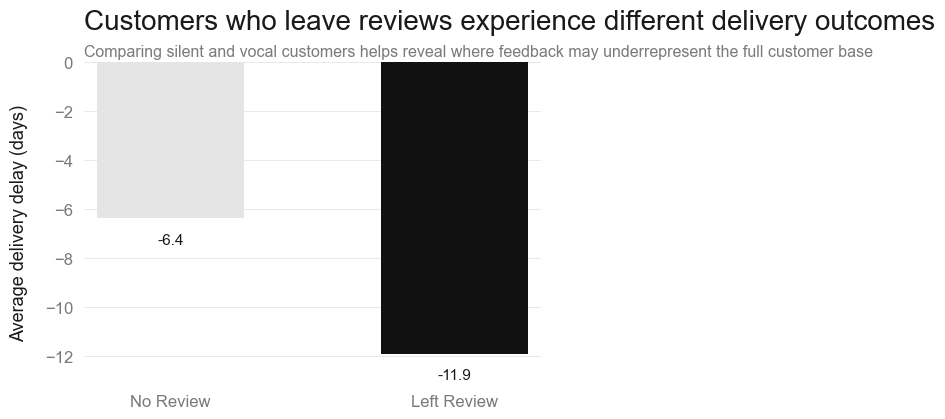

In [263]:
fig, ax = create_figure(figsize=(8, 5))

bars = ax.bar(
    review_behavior.index,
    review_behavior["delivery_delay"],
    color=[LIGHT, ACCENT],
    width=0.52
)

add_title(
    ax,
    "Customers who leave reviews experience different delivery outcomes",
    "Comparing silent and vocal customers helps reveal where feedback may underrepresent the full customer base"
)

ax.set_ylabel("Average delivery delay (days)")
clean_axes(ax, grid_axis="y")

for bar in bars:
    h = bar.get_height()
    offset = 0.4 if h >= 0 else -0.6
    ax.text(
        bar.get_x() + bar.get_width()/2,
        h + offset,
        f"{h:.1f}",
        ha="center",
        va="bottom" if h >= 0 else "top",
        fontsize=11,
        color=DARK
    )

plt.tight_layout(pad=3)
plt.show()
save_fig(fig, "11_reviewed_vs_silent_delivery_delay.png")

This chart adds a more realistic business lens: the absence of a review does not necessarily mean the absence of friction.

If reviewed and non-reviewed orders differ systematically, then explicit customer feedback may represent only one visible part of the overall customer experience.

### Chart 12 — dissatisfaction risk concentration

In [264]:
reviewed_df["risk_segment"] = pd.cut(
    reviewed_df["delivery_delay"],
    bins=[-30, -3, 0, 3, 30],
    labels=["Very Early", "Slightly Early", "On Time", "Late"]
)

In [265]:
reviewed_df["value_segment"] = pd.qcut(
    reviewed_df["order_value"],
    q=3,
    labels=["Low Value", "Mid Value", "High Value"]
)

In [266]:
risk_matrix = (
    reviewed_df.groupby(["risk_segment", "value_segment"])["is_dissatisfied"]
    .mean()
    .unstack()
    * 100
)

risk_matrix

/var/folders/0_/937qdrnn19vgx61scsk5r5j40000gn/T/ipykernel_61274/3613721635.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  reviewed_df.groupby(["risk_segment", "value_segment"])["is_dissatisfied"]


value_segment,Low Value,Mid Value,High Value
risk_segment,,,
Very Early,7.516970,8.568232,11.281731
Slightly Early,10.146777,11.243851,14.165391
On Time,28.119800,36.523126,31.687898
Late,75.468484,74.061196,76.163873


Late deliveries appear to be the most concentrated dissatisfaction risk zone across value segments.

This makes late delivery the clearest operational priority for intervention.

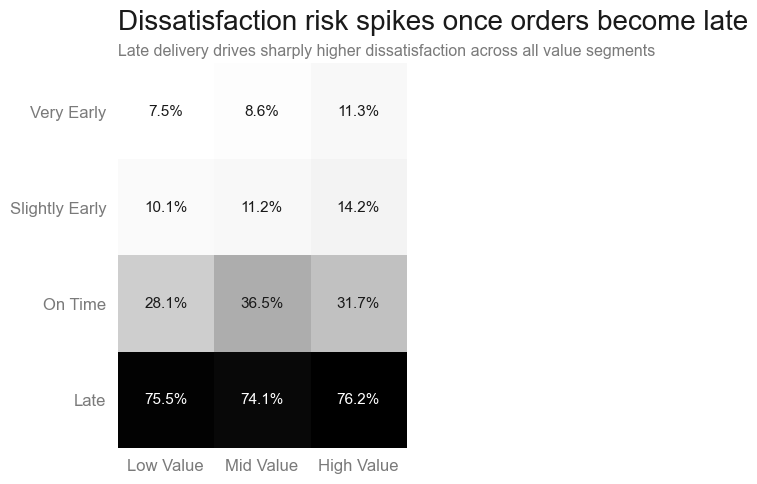

In [267]:
fig, ax = create_figure(figsize=(8, 5))

im = ax.imshow(risk_matrix, cmap="Greys")

ax.set_xticks(range(len(risk_matrix.columns)))
ax.set_yticks(range(len(risk_matrix.index)))
ax.set_xticklabels(risk_matrix.columns)
ax.set_yticklabels(risk_matrix.index)

add_title(
    ax,
    "Dissatisfaction risk spikes once orders become late",
    "Late delivery drives sharply higher dissatisfaction across all value segments"
)

clean_axes(ax, grid_axis="both")
ax.grid(False)

for i in range(risk_matrix.shape[0]):
    for j in range(risk_matrix.shape[1]):
        value = risk_matrix.iloc[i, j]
        ax.text(
            j, i, f"{value:.1f}%",
            ha="center", va="center",
            color="white" if value > 40 else DARK,
            fontsize=11
        )

plt.tight_layout()
plt.show()

save_fig(fig, "12_dissatisfaction_risk_concentration.png")

The main takeaway is not that high-value orders are uniquely fragile, but that late delivery is the dominant failure point across the experience.

From a business perspective, reducing late deliveries is likely to be the single highest-impact operational lever for reducing dissatisfaction.

In [268]:
df.to_csv("../data/processed/main_dataset.csv", index=False)